In [146]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

In [147]:
OUTPUTS_DIR = Path("/Users/hyeon/SeSAC_Project/PoC/run/test8/outputs")
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

In [148]:
pose_data

{'frames': [{'image_path': 'run/test8/inputs/00000100.png',
   'people': [{'track_id': 0,
     'bbox': [1529.1895751953125,
      231.22938537597656,
      1907.5775146484375,
      959.0892333984375],
     'bbox_score': 1.0,
     'keypoints': [[1559.6380598280166, 307.28503942489624],
      [1570.3000700208877, 294.2536942164104],
      [1558.4533920288086, 294.2536942164104],
      [1621.2407853868272, 302.5463684399922],
      [1616.5021141899956, 296.6230297088623],
      [1650.857480367025, 365.33375898996997],
      [1607.0247717963325, 389.02711391448975],
      [1727.860887315538, 449.4451689720154],
      [1612.948110792372, 486.1698691050211],
      [1643.7494735717773, 538.2952499389648],
      [1579.7774124145508, 534.7412467002869],
      [1676.9201719495986, 593.9746340115867],
      [1622.4254531860352, 592.7899662653604],
      [1680.4741753472222, 764.5667894681294],
      [1598.7320972018772, 759.8281184832256],
      [1852.2510062323677, 824.984844525655],
      [164

In [149]:
pose_data["frames"].__len__()

94

In [150]:
Halpe_26_keypoints = {
    0: "nose",
    1: "left_eye",
    2: "right_eye",
    3: "left_ear",
    4: "right_ear",
    5: "left_shoulder",
    6: "right_shoulder",
    7: "left_elbow",
    8: "right_elbow",
    9: "left_wrist",
    10: "right_wrist",
    11: "left_hip",
    12: "right_hip",
    13: "left_knee",
    14: "right_knee",
    15: "left_ankle",
    16: "right_ankle",
    17: "head",
    18: "neck",
    19: "hip_center",
    20: "left_big_toe",
    21: "right_big_toe",
    22: "left_small_toe",
    23: "right_small_toe",
    24: "left_heel",
    25: "right_heel",
}

In [151]:
def hpe2pd(pose_data: dict) -> pd.DataFrame:
    """
    hpe json 데이터를 pandas DataFrame으로 변경
    Returns:
        pd.DataFrame has bbox(4), keypoints(26)
    """
    rows = []
    
    for frame in pose_data["frames"]:
        row = {}

        if frame['people'] == []:
            # 사람이 포착되지 않음.
            continue
        bbox = frame['people'][0]["bbox"]
        row["bbox_left"], row["bbox_up"], row["bbox_right"], row["bbox_down"] = bbox

        for i, xy in enumerate(frame['people'][0]['keypoints']):
            row[f"{Halpe_26_keypoints[i]}_x"] = xy[0]
            row[f"{Halpe_26_keypoints[i]}_y"] = xy[1]
        rows.append(row)
    
    return pd.DataFrame.from_records(rows)

In [152]:
df = hpe2pd(pose_data)
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1529.189575,231.229385,1907.577515,959.089233,1559.638060,307.285039,1570.300070,294.253694,1558.453392,294.253694,...,1566.746067,928.050938,1866.467020,855.786206,1578.592745,922.127600,1880.683033,815.507503,1667.442830,930.420274
1,1517.395752,236.541962,1860.677612,958.600525,1545.659101,310.816188,1555.060905,296.713481,1543.308650,296.713481,...,1573.864515,926.634389,1833.589367,846.719050,1583.266319,920.758261,1845.341623,818.513636,1676.109140,926.634389
2,1510.258423,239.091385,1720.509521,958.192566,1529.943953,311.891012,1541.648073,297.846067,1528.773540,297.846067,...,1573.249199,925.186934,1787.434607,853.791798,1584.953320,919.334873,1810.842848,817.509024,1675.075048,926.357346
3,1492.887939,241.800476,1767.756958,960.283264,1512.212542,311.029277,1523.906598,295.827003,1511.043137,296.996409,...,1571.852229,930.814255,1772.989995,889.885058,1584.715691,924.967227,1782.345240,829.075966,1672.421112,929.644849
4,1480.325806,239.608215,1753.995483,960.091736,1498.721794,306.684491,1509.275751,292.612547,1496.376470,293.785209,...,1572.599493,932.885967,1716.836905,924.677333,1583.153450,925.849995,1742.635466,848.454307,1672.275753,923.504671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,97.377869,204.865128,393.036163,951.605530,201.452694,280.462882,207.529683,267.093506,205.098887,264.662710,...,139.467404,872.361628,340.008047,924.623734,147.975189,869.930832,387.408563,862.638445,212.391274,899.100380
90,81.122643,202.759644,389.718384,947.406982,189.364851,279.357472,195.424807,266.025569,194.212816,263.601587,...,116.645379,863.537207,334.803796,921.712782,121.493344,863.537207,378.435479,855.053269,186.940869,899.896942
91,69.187180,200.590393,383.724426,948.572083,177.759085,281.183472,182.628757,266.574455,181.411339,264.139619,...,97.409488,858.239658,327.501516,922.762818,97.409488,860.674495,370.111151,849.717732,159.497813,902.066711
92,45.208214,204.050629,367.462219,944.182800,164.172740,281.388621,171.400594,266.932914,168.991309,266.932914,...,79.847779,858.412281,321.980881,919.849038,79.847779,859.616923,362.938719,845.161216,141.284536,902.984046


### 결측치 검사

In [153]:
df.isna().sum().sum()

np.int64(0)

In [154]:
df.describe()

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,...,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,770.570430,216.256382,1092.149583,958.530945,840.715685,287.096388,850.743670,273.706964,842.145218,272.331993,...,936.396504,908.658944,923.154300,921.683277,942.961188,901.687623,984.611551,892.414907,998.979280,872.664130
std,446.970672,21.846446,446.951885,5.655447,425.211486,18.193420,426.522667,18.474918,423.093134,18.476130,...,458.612301,23.369652,463.426719,18.629767,458.215188,22.324918,457.197598,41.739934,462.475268,46.373759
min,30.932945,174.761032,354.170380,944.182800,151.643435,255.064841,158.862534,241.088725,156.456168,239.818169,...,61.404689,858.239658,312.869994,846.719050,63.811055,859.616923,350.168676,812.819974,123.970219,790.822985
25%,324.163773,199.036560,748.370743,955.095749,465.917444,271.787427,474.172957,257.802275,468.364229,256.941950,...,710.885053,891.591269,352.748885,911.798147,711.501521,883.225744,429.514366,851.051616,720.691277,827.009467
50%,751.393341,213.830338,1137.811218,958.707031,841.671873,285.234385,851.418144,271.914000,845.940722,270.948011,...,770.795773,907.996773,1102.988907,926.758398,783.199203,896.173587,1110.922318,913.445097,863.542723,884.301027
75%,1169.466705,235.422092,1491.718964,962.635300,1210.742776,303.307119,1221.721705,290.427086,1208.604731,288.006681,...,1439.791703,931.764440,1205.129462,934.457634,1440.408149,924.952339,1287.382798,925.990563,1470.905175,912.958069
max,1529.189575,254.219482,1907.577515,971.639282,1559.638060,317.294731,1570.300070,304.725386,1558.453392,302.440050,...,1588.576604,943.719512,1866.467020,945.656152,1609.152731,936.572244,1880.683033,938.284690,1676.109140,934.023846


In [155]:
left_ankle_x = df["left_ankle_x"]
type(left_ankle_x)

pandas.Series

In [156]:
details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    details_data = json.load(file)

In [157]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1529.189575,231.229385,1907.577515,959.089233,1559.638060,307.285039,1570.300070,294.253694,1558.453392,294.253694,...,1566.746067,928.050938,1866.467020,855.786206,1578.592745,922.127600,1880.683033,815.507503,1667.442830,930.420274
1,1517.395752,236.541962,1860.677612,958.600525,1545.659101,310.816188,1555.060905,296.713481,1543.308650,296.713481,...,1573.864515,926.634389,1833.589367,846.719050,1583.266319,920.758261,1845.341623,818.513636,1676.109140,926.634389
2,1510.258423,239.091385,1720.509521,958.192566,1529.943953,311.891012,1541.648073,297.846067,1528.773540,297.846067,...,1573.249199,925.186934,1787.434607,853.791798,1584.953320,919.334873,1810.842848,817.509024,1675.075048,926.357346
3,1492.887939,241.800476,1767.756958,960.283264,1512.212542,311.029277,1523.906598,295.827003,1511.043137,296.996409,...,1571.852229,930.814255,1772.989995,889.885058,1584.715691,924.967227,1782.345240,829.075966,1672.421112,929.644849
4,1480.325806,239.608215,1753.995483,960.091736,1498.721794,306.684491,1509.275751,292.612547,1496.376470,293.785209,...,1572.599493,932.885967,1716.836905,924.677333,1583.153450,925.849995,1742.635466,848.454307,1672.275753,923.504671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,97.377869,204.865128,393.036163,951.605530,201.452694,280.462882,207.529683,267.093506,205.098887,264.662710,...,139.467404,872.361628,340.008047,924.623734,147.975189,869.930832,387.408563,862.638445,212.391274,899.100380
90,81.122643,202.759644,389.718384,947.406982,189.364851,279.357472,195.424807,266.025569,194.212816,263.601587,...,116.645379,863.537207,334.803796,921.712782,121.493344,863.537207,378.435479,855.053269,186.940869,899.896942
91,69.187180,200.590393,383.724426,948.572083,177.759085,281.183472,182.628757,266.574455,181.411339,264.139619,...,97.409488,858.239658,327.501516,922.762818,97.409488,860.674495,370.111151,849.717732,159.497813,902.066711
92,45.208214,204.050629,367.462219,944.182800,164.172740,281.388621,171.400594,266.932914,168.991309,266.932914,...,79.847779,858.412281,321.980881,919.849038,79.847779,859.616923,362.938719,845.161216,141.284536,902.984046


In [158]:
df["bbox_down"].diff()

0          NaN
1    -0.488708
2    -0.407959
3     2.090698
4    -0.191528
        ...   
89    0.456848
90   -4.198547
91    1.165100
92   -4.389282
93    2.500305
Name: bbox_down, Length: 94, dtype: float64

In [159]:
def vel_acc(df: pd.DataFrame, keypoints: list[str] = None,fps: float = 60.0, one_arrow: str = None):
    """
    정해진 형식의 df에서 구하고자 하는 키포인트의 속력(vel)과 가속력(acc)를 구한다.
    Returns:
        pd.DataFrame
    """
    if fps <= 0:
        raise ValueError("fps는 0보다 커야 합니다.")
    
    if keypoints is None:
        keypoints = list(Halpe_26_keypoints.values())
    if type(keypoints) == str:
        keypoints = list(keypoints)

    dt = 1 / fps

    res = pd.DataFrame()

    for key in keypoints:
        vx = df[f"{key}_x"].diff() / dt
        vy = df[f"{key}_y"].diff() / dt
        ax = vx.diff() / dt
        ay = vy.diff() / dt
        
        if one_arrow == 'x':
            res[f"{key}_x_vel"] = vx.abs()
            res[f"{key}_x_acc"] = ax.abs()
        if one_arrow == 'y':
            res[f"{key}_y_vel"] = vy.abs()
            res[f"{key}_y_acc"] = ay.abs()
        else:
            res[f"{key}_vel"] = np.hypot(vx, vy)
            res[f"{key}_acc"] = np.hypot(ax, ay)

    return res.iloc[2:]

In [160]:
vel_acc_df = vel_acc(df, fps=25)
vel_acc_df

,nose_vel,nose_acc,left_eye_vel,left_eye_acc,right_eye_vel,right_eye_acc,left_ear_vel,left_ear_acc,right_ear_vel,right_ear_acc,...,right_big_toe_vel,right_big_toe_acc,left_small_toe_vel,left_small_toe_acc,right_small_toe_vel,right_small_toe_acc,left_heel_vel,left_heel_acc,right_heel_vel,right_heel_acc
2,393.796532,1879.980707,336.514136,1411.026404,364.479211,912.823439,341.361918,2857.872412,201.326933,9337.422083,...,39.320332,4833.640973,1167.338228,13062.022473,55.181540,1866.914644,862.834976,2561.441954,26.763992,6447.194007
3,443.808448,1747.272262,446.399868,3346.526217,443.768761,2350.133303,445.084084,2880.060137,211.687909,2015.026623,...,144.953160,4448.641501,971.908639,26865.723157,140.934100,4570.954817,768.890348,8706.543864,105.626281,2447.088109
4,354.328110,3429.812671,374.495016,2082.757038,375.352259,2417.656876,365.920163,2177.406857,187.353697,612.120540,...,55.059022,2595.074819,1651.452382,26080.477878,44.860034,3081.773265,1104.645372,8540.588381,153.547459,6097.327213
5,432.661699,2127.888061,403.507106,2339.829493,422.436733,3075.761040,407.383016,2968.465496,1566.167683,34471.953541,...,37.400694,2118.241252,1106.878331,16916.897199,98.859746,1355.271786,843.406085,6756.771605,614.488495,16871.731654
6,345.458831,3481.830411,371.478562,3215.375237,374.342057,4706.376765,393.023903,1691.363430,855.444937,17789.921598,...,213.313369,5917.250257,1179.529444,9512.912800,284.802775,9581.015968,1433.496126,17592.246742,252.894772,21206.030538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,259.778354,1724.168699,259.559786,1462.162216,289.940466,1456.268341,292.148422,575.913797,260.474730,1319.051722,...,760.854411,2268.904030,45.679869,3461.854327,790.329268,2420.283634,260.019457,1148.530784,745.154493,1880.213150
90,303.457033,1107.208361,303.797330,1115.400185,273.441645,486.071202,305.554390,641.232277,307.407582,1803.357371,...,611.716459,4817.348957,149.076062,2587.447983,681.068360,2905.948777,293.737898,1642.314101,636.571706,2740.397681
91,293.713389,1856.740540,320.195413,1098.975766,320.319453,1559.506212,256.744231,1597.765490,321.278267,1809.960023,...,498.800772,3143.643399,184.434713,2801.447162,606.334916,2667.637108,247.187167,1463.322195,688.217453,1512.494089
92,339.697342,1599.542149,280.847104,987.129850,318.256625,1429.558985,349.874376,2354.587733,328.768755,1773.090355,...,439.063918,3575.396664,156.059949,2716.133628,439.838079,4229.590057,212.434729,869.118104,455.909080,5821.478976


In [161]:
vel_acc_df["left_big_toe_acc"].name

'left_big_toe_acc'

In [162]:
def visualize_time(_df: pd.DataFrame, fps: float) -> None:
    if type(_df) == pd.Series:
        _df = _df.to_frame()
    time = (_df.index.to_numpy() - 2) / fps

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in _df.columns:
        axes.plot(time, _df[col], label=col, linewidth=1.5)
    axes.set_title("Time Series Analysis")
    axes.set_xlabel("Time (s)")
    axes.set_ylabel("pixel")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [163]:
df["right_instep_x"] = (df["right_big_toe_x"] + df["right_ankle_x"]) / 2
df["right_instep_y"] = (df["right_big_toe_y"] + df["right_ankle_y"]) / 2

In [164]:
df_test = vel_acc(df, ["right_instep"], 50, one_arrow='y')["right_instep_y_acc"]

In [165]:
df_test2 = vel_acc(df, ["left_heel"], 50, one_arrow='y')["left_heel_y_vel"]


In [166]:
df_test2.loc[13] = 2000

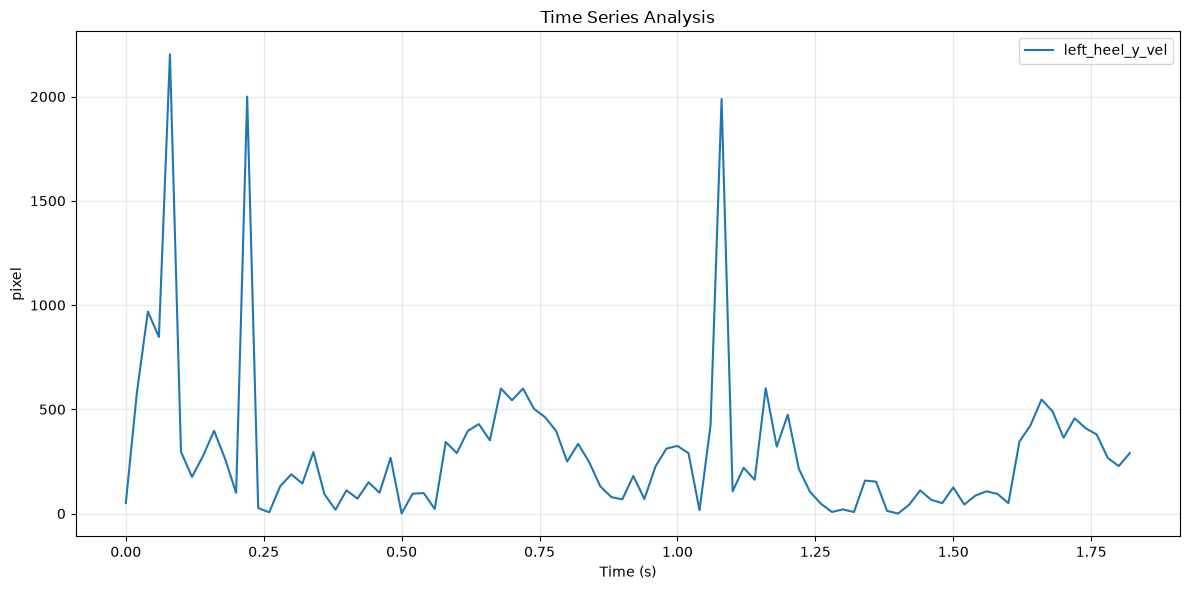

In [167]:
visualize_time(df_test2, 50)

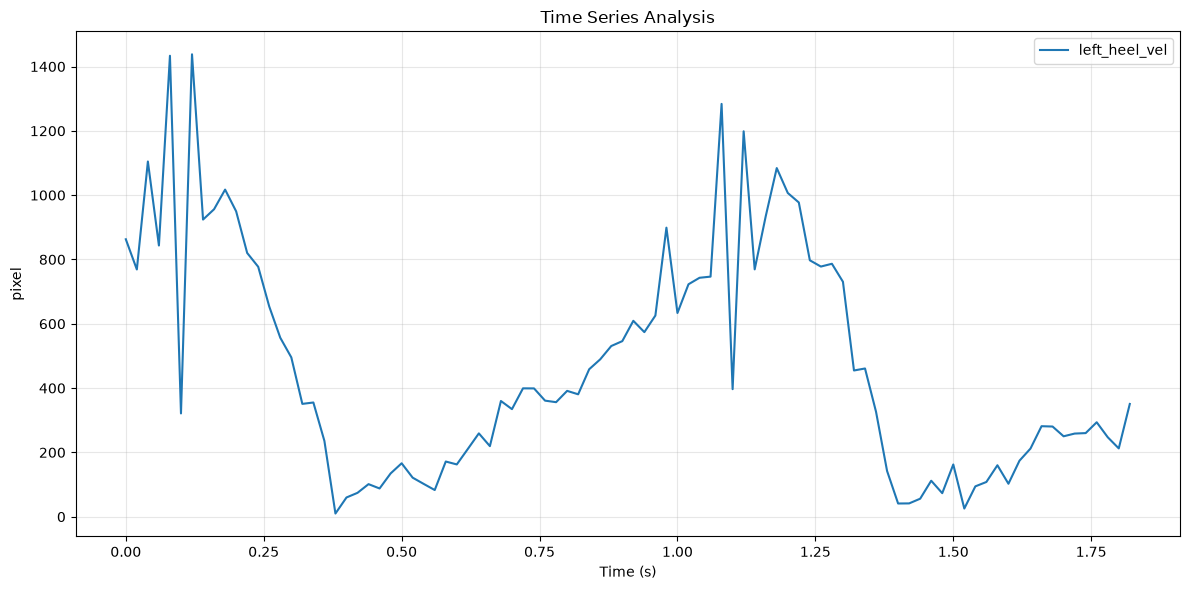

In [168]:
visualize_time(vel_acc_df["left_heel_vel"], 50)

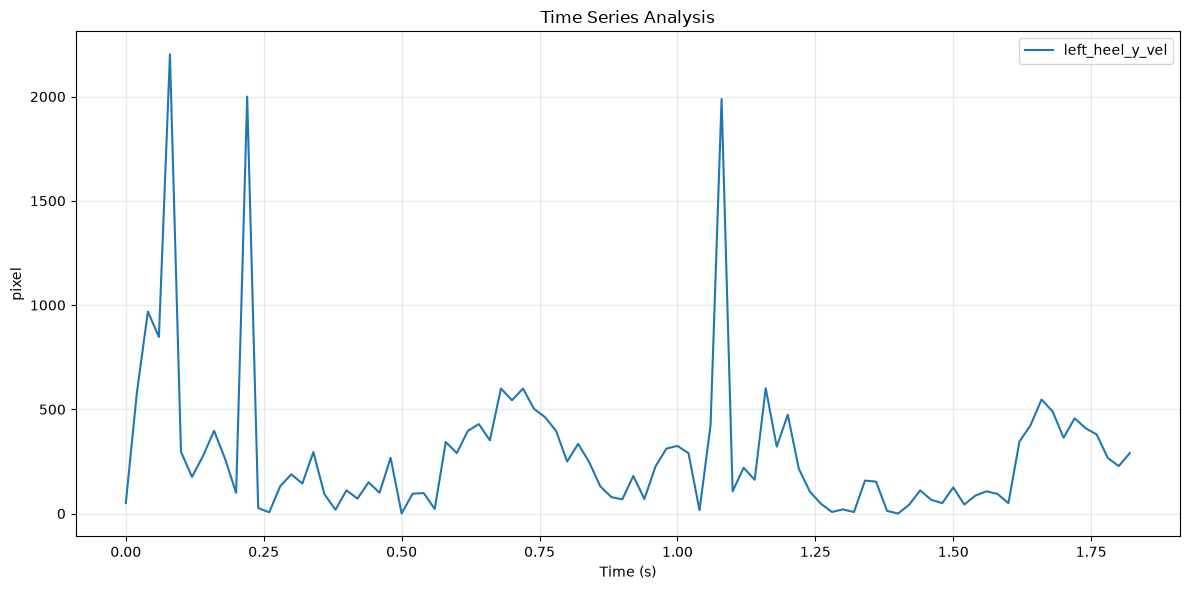

In [169]:
visualize_time(df_test2, 50)

In [170]:
'_'.join("left_heel_x".split('_')[:-1])

'left_heel'

In [171]:
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.plot(df["left_heel_x"], 1080 - df["left_heel_y"])
# fig.tight_layout()
# fig.show()
def visualize_xy(_df: pd.DataFrame, height: int) -> None:
    if type(_df) == pd.Series:
        raise RuntimeError("x, y가 주어져야 합니다.")
    columns = set('_'.join(col.split('_')[:-1]) for col in _df.columns)

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in columns:
        axes.plot(_df[f"{col}_x"], height - _df[f"{col}_y"], label=col, linewidth=1.5)
    axes.set_title("Trace Analysis")
    axes.set_xlabel("x")
    axes.set_ylabel("y")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [172]:
def gct(df, side: str):
    """
    {side}의 heel이 지면에 접촉하고 big_toe가 지면에서 떼어지는 순간까지의 인덱스 출력
    """
    heel = f"{side}_heel"
    start = int(df[f"{heel}_y"].argmax())

    toe = f"{side}_big_toe"
    min_value = df[f"{toe}_y"].max()

    inside = df[f"{toe}_y"].between(min_value - 5, min_value)
    end = df.index[~inside & inside.shift(1, fill_value=False)].to_list()[0]
    return start - 1, end - 1




In [173]:
gct(df, "left")

(29, 5)

In [174]:
gct(df, "right")

(54, 55)

In [175]:
heel = "left_heel"
max_value = df[f"{heel}_y"].argmax()

In [176]:
max_value - 1

np.int64(29)

In [177]:
df[f"{heel}_y"]

0     815.507503
1     818.513636
2     817.509024
3     829.075966
4     848.454307
         ...    
89    862.638445
90    855.053269
91    849.717732
92    845.161216
93    839.359152
Name: left_heel_y, Length: 94, dtype: float64

In [178]:
[df[f"{heel}_y"] > max_value - 10]

[0     True
 1     True
 2     True
 3     True
 4     True
       ... 
 89    True
 90    True
 91    True
 92    True
 93    True
 Name: left_heel_y, Length: 94, dtype: bool]

In [179]:
#    13: "left_knee",
#    14: "right_knee",

In [180]:
lkv = vel_acc_df["left_knee_vel"].to_frame()
lka = vel_acc_df["left_knee_acc"].to_frame()


In [181]:
fps = 25

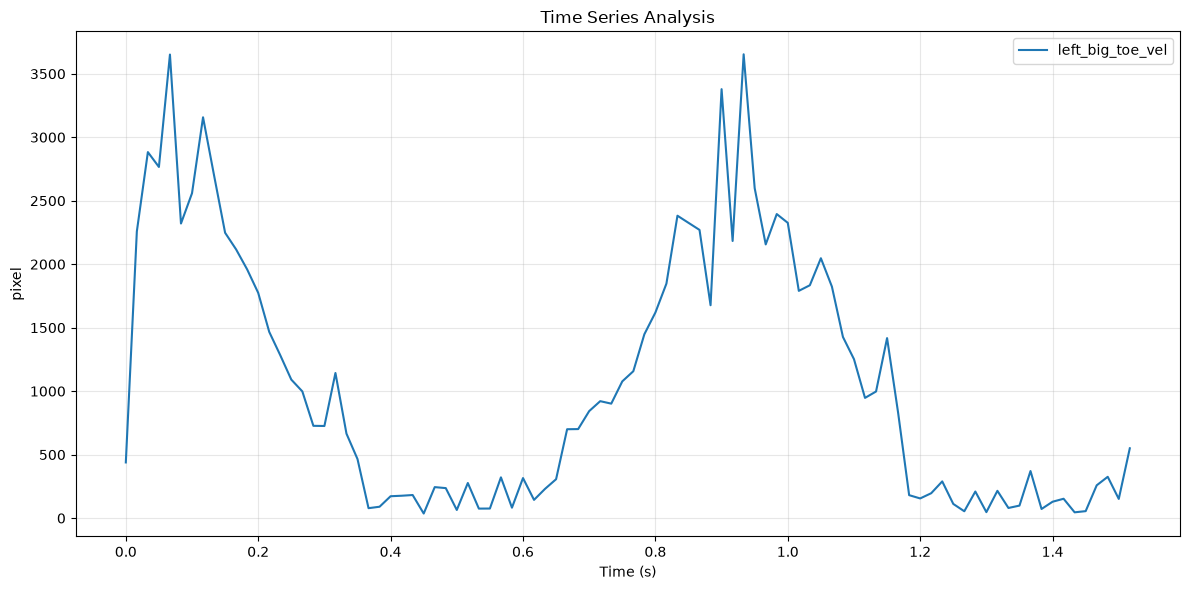

In [182]:
visualize_time(vel_acc(df, ["left_big_toe"], fps=60)["left_big_toe_vel"], 60)

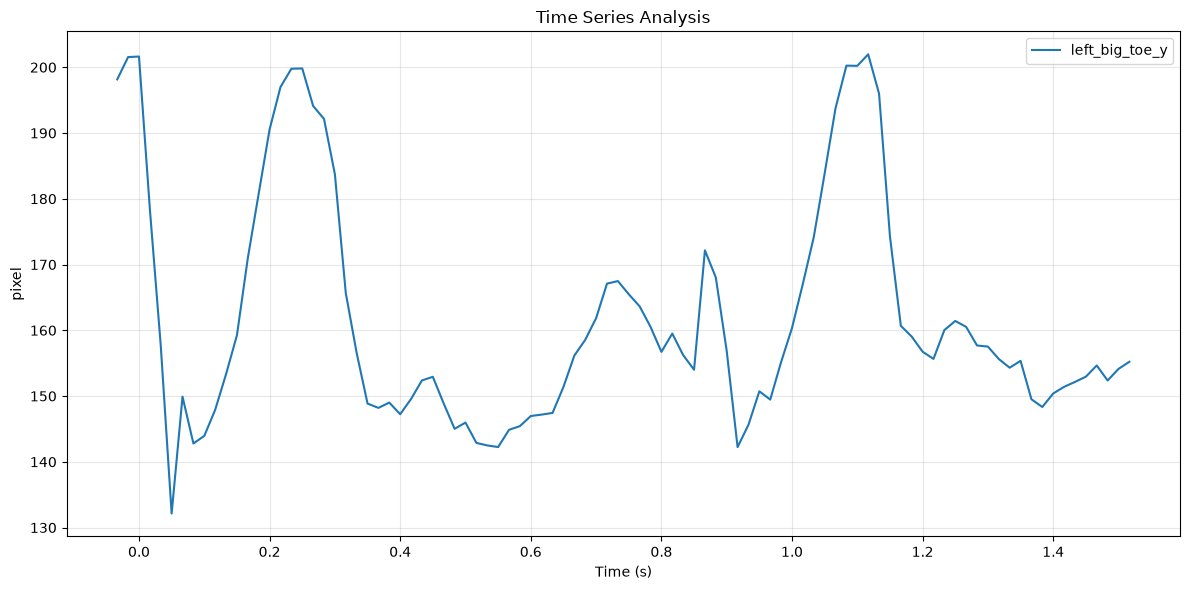

In [183]:
visualize_time(1080 - df["left_big_toe_y"], 60)

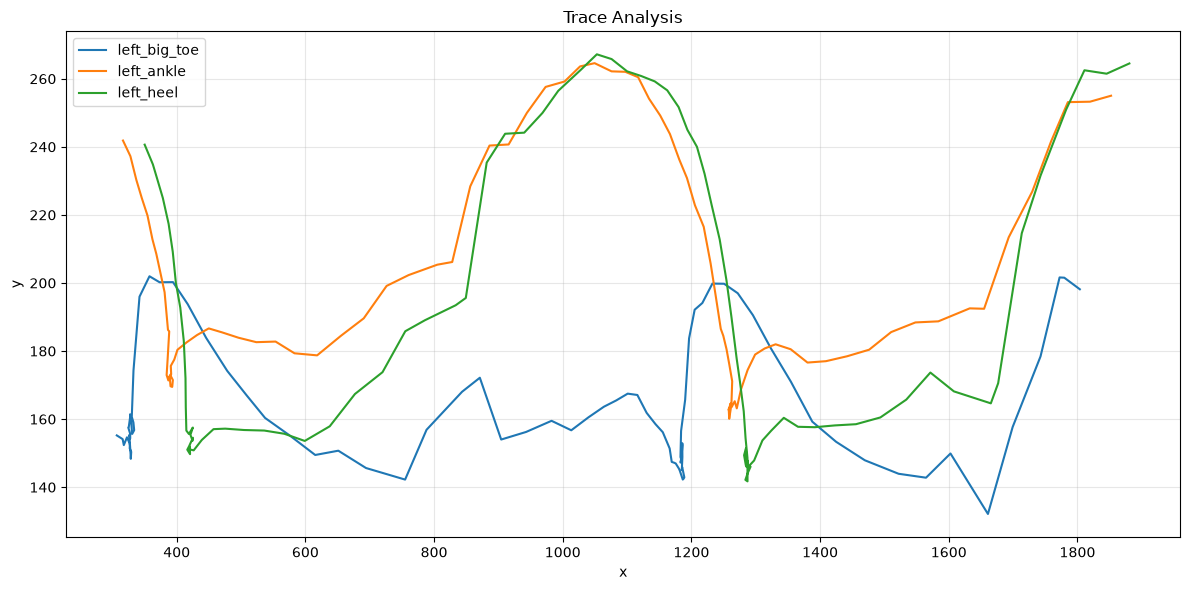

In [184]:
visualize_xy(df[["left_heel_x", "left_heel_y", "left_big_toe_x", "left_big_toe_y", "left_ankle_x", "left_ankle_y"]], 1080)

In [185]:
# def knee_flexion_angle(hip, knee, ankle) -> float:

#     thigh = (np.asarray(hip, dtype=float) - np.asarray(knee, dtype=float)).T

#     shank = (np.asarray(ankle, dtype=float) - np.asarray(knee, dtype=float)).T

#     denominator = np.linalg.norm(thigh, axis=1) * np.linalg.norm(shank, axis=1)

#     # if denominator == 0 or not np.isfinite(denominator):
#     #     return np.nan
#     cosine = np.clip(np.sum((thigh * shank), axis=1) / denominator, -1.0, 1.0)

#     joint_angle = np.clip(np.degrees(np.arccos(cosine)), 0, 180)

#     return 180.0 - joint_angle

In [186]:
def knee_flexion_angle(
    hip,
    knee,
    ankle,
    orientation: float = 1.0,
) -> np.ndarray:
    """
    무릎 굴곡 각도를 계산한다.

    반환값:
        정상 굴곡: 양수
        완전 신전: 0
        반대 방향 과신전: 음수

    orientation:
        촬영 방향 때문에 부호가 반대이면 -1.0을 전달한다.
    """
    thigh = (
        np.asarray(hip, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    shank = (
        np.asarray(ankle, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    thigh_norm = np.linalg.norm(thigh, axis=1)
    shank_norm = np.linalg.norm(shank, axis=1)

    valid = (
        np.isfinite(thigh_norm)
        & np.isfinite(shank_norm)
        & (thigh_norm > 1e-8)
        & (shank_norm > 1e-8)
    )

    result = np.full(len(thigh), np.nan, dtype=float)

    dot = np.sum(thigh[valid] * shank[valid], axis=1)

    cross = (
        thigh[valid, 0] * shank[valid, 1]
        - thigh[valid, 1] * shank[valid, 0]
    )

    # 무릎을 중심으로 한 두 벡터의 방향 포함 각도
    signed_joint_angle = np.degrees(
        np.arctan2(cross, dot)
    )

    direction = np.where(signed_joint_angle >= 0, 1.0, -1.0)

    result[valid] = (
        orientation
        * direction
        * (180.0 - np.abs(signed_joint_angle))
    )

    # 부동소수점으로 생기는 극소값 제거
    result[np.isclose(result, 0.0, atol=1e-8)] = 0.0

    return result

In [187]:
df["left_hip_y"].shape

(94,)

In [188]:
help(np.arctan2)

Help on ufunc in module numpy:

arctan2 = <ufunc 'arctan2'>
    arctan2(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Element-wise arc tangent of ``x1/x2`` choosing the quadrant correctly.

    The quadrant (i.e., branch) is chosen so that ``arctan2(x1, x2)`` is
    the signed angle in radians between the ray ending at the origin and
    passing through the point (1,0), and the ray ending at the origin and
    passing through the point (`x2`, `x1`).  (Note the role reversal: the
    "`y`-coordinate" is the first function parameter, the "`x`-coordinate"
    is the second.)  By IEEE convention, this function is defined for
    `x2` = +/-0 and for either or both of `x1` and `x2` = +/-inf (see
    Notes for specific values).

    This function is not defined for complex-valued arguments; for the
    so-called argument of complex values, use `angle`.

    Parameters
    ----------
    x1 : array_like, real-valued
        `y`-co

In [189]:
df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y', 'right_instep_x', 'right_inst

In [190]:
(df["nose_x"] - df["neck_x"])[0]

np.float64(-59.23338996039479)

In [191]:
left_knee_angle = knee_flexion_angle(
    [df["left_hip_x"], df["left_hip_y"]],
    [df["left_knee_x"], df["left_knee_y"]],
    [df["left_ankle_x"], df["left_ankle_y"]]
)

In [192]:
1 == True

True

In [193]:
발착지예상프레임 = left_knee_angle.argmin() - 1

In [194]:
발착지예상프레임

np.int64(66)

In [195]:
df["left_heel_y"]

0     815.507503
1     818.513636
2     817.509024
3     829.075966
4     848.454307
         ...    
89    862.638445
90    855.053269
91    849.717732
92    845.161216
93    839.359152
Name: left_heel_y, Length: 94, dtype: float64

In [196]:
TD = df["left_heel_y"].argmax()

In [197]:
TD

np.int64(30)

In [198]:
left_knee_angle

array([69.42850727, 71.60108302, 78.86479022, 75.82044178, 74.39986902,
       73.05753989, 69.7099692 , 66.99852057, 56.89286568, 49.22076779,
       40.64743644, 29.14877373, 20.78540647, 10.53271203,  6.12908076,
        2.24842812, -0.37345105,  1.09242929,  4.05243835,  7.47671408,
       10.48081843, 13.51025735, 20.3998117 , 28.16178459, 33.25854429,
       38.91051835, 37.77299335, 39.55142044, 38.15531679, 31.70729383,
       28.25600787, 23.86534513, 25.04705144, 28.89413158, 28.17457462,
       25.87362427, 24.08436269, 21.67804134, 24.31047682, 24.32693235,
       27.92171923, 29.4758893 , 33.45716844, 37.08882724, 41.07634767,
       48.43097818, 52.09041588, 58.50336417, 64.92548796, 69.07549783,
       70.91093034, 83.89240084, 84.88810458, 73.81234799, 79.2471895 ,
       74.25554035, 65.98625668, 65.25461291, 55.61192785, 48.75173092,
       39.42998359, 30.46232546, 19.32265937, 10.51969619,  7.89656945,
        3.3965872 , -1.74474056, -2.55425221, -1.21838513, -0.61

In [199]:
left_knee_angle[12]

np.float64(20.785406473278897)

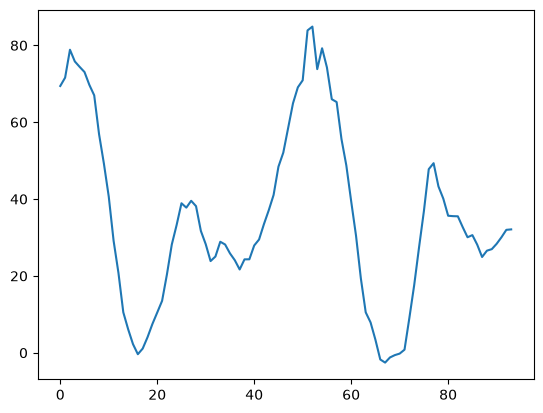

In [200]:
plt.plot(left_knee_angle)

In [201]:
y = np.asarray(left_knee_angle, dtype=float)
x = np.arange(len(y))

In [202]:
y_smooth = savgol_filter(
    y,
    window_length=5,
    polyorder=2
)

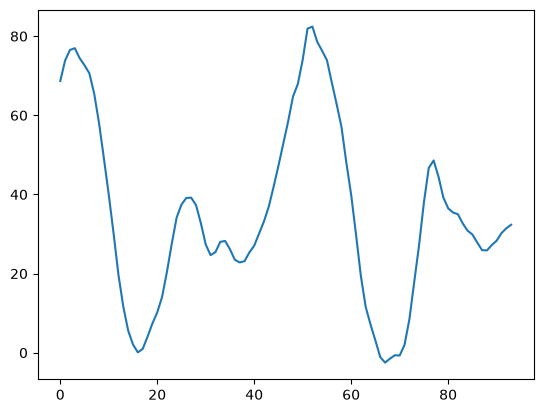

In [203]:
plt.plot(y_smooth)

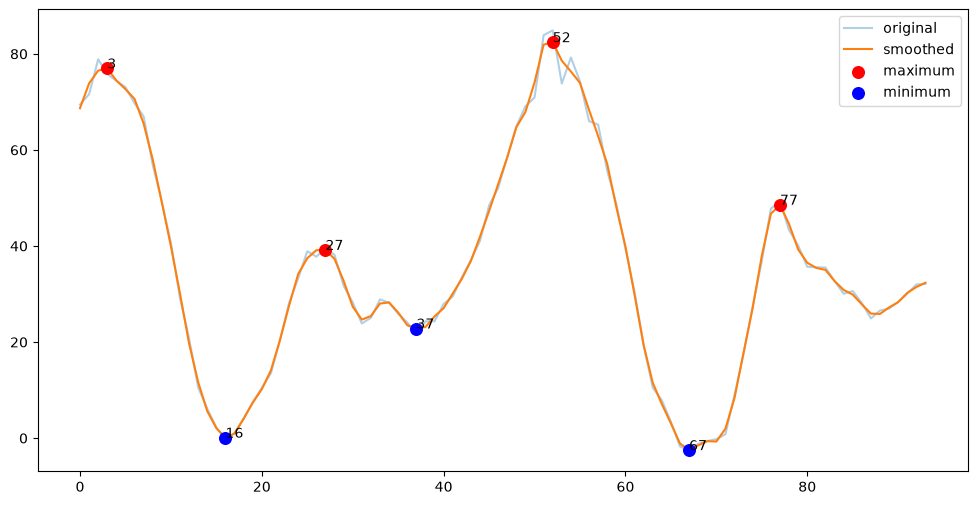

최댓값 프레임: [ 3 27 52 77]
최솟값 프레임: [16 37 67]


In [204]:
# 데이터 범위에 비례해 prominence 설정
signal_range = np.percentile(y_smooth, 95) - np.percentile(y_smooth, 5)
prominence = signal_range * 0.10    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

# 최댓값
max_indices, max_properties = find_peaks(
    y_smooth,
    prominence=prominence,
    distance=10,
)

# 최솟값: 신호에 -를 붙여서 봉우리로 변환
min_indices, min_properties = find_peaks(
    -y_smooth,
    prominence=prominence,
    distance=10,
)

plt.figure(figsize=(12, 6))
plt.plot(x, y, alpha=0.35, label="original")
plt.plot(x, y_smooth, label="smoothed")

plt.scatter(
    max_indices,
    y_smooth[max_indices],
    color="red",
    s=70,
    label="maximum",
    zorder=3,
)

plt.scatter(
    min_indices,
    y_smooth[min_indices],
    color="blue",
    s=70,
    label="minimum",
    zorder=3,
)

for i in max_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

for i in min_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

plt.legend()
plt.show()

print("최댓값 프레임:", max_indices)
print("최솟값 프레임:", min_indices)

In [205]:
_max = {
    "frame": max_indices,
    "class": np.ones_like(max_indices)
}
_min = {
    "frame": min_indices,
    "class": np.zeros_like(min_indices)
}
extremum = pd.concat([pd.DataFrame(_max), pd.DataFrame(_min)]).sort_values('frame')


In [206]:
extremum

,frame,class
0,3,1
0,16,0
1,27,1
1,37,0
2,52,1
2,67,0
3,77,1


In [207]:
for i in range(1, len(extremum)):
    previous = extremum["class"].iloc[i - 1]
    current = extremum["class"].iloc[i]

    assert {previous, current} == {0, 1}, (
        f"예외: {i-1}, {i}행의 값이 {previous}, {current}입니다."
    )


In [208]:
res = []
for i in range(len(extremum) // 4 + 1):
    res.append(extremum['frame'].iloc[4 * i : 4 * i + 5].to_list())

In [209]:
res

[[3, 16, 27, 37, 52], [52, 67, 77]]

In [210]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y,right_instep_x,right_instep_y
0,1529.189575,231.229385,1907.577515,959.089233,1559.638060,307.285039,1570.300070,294.253694,1558.453392,294.253694,...,1866.467020,855.786206,1578.592745,922.127600,1880.683033,815.507503,1667.442830,930.420274,1607.024772,920.350598
1,1517.395752,236.541962,1860.677612,958.600525,1545.659101,310.816188,1555.060905,296.713481,1543.308650,296.713481,...,1833.589367,846.719050,1583.266319,920.758261,1845.341623,818.513636,1676.109140,926.634389,1609.708895,918.995423
2,1510.258423,239.091385,1720.509521,958.192566,1529.943953,311.891012,1541.648073,297.846067,1528.773540,297.846067,...,1787.434607,853.791798,1584.953320,919.334873,1810.842848,817.509024,1675.075048,926.357346,1611.872797,918.164461
3,1492.887939,241.800476,1767.756958,960.283264,1512.212542,311.029277,1523.906598,295.827003,1511.043137,296.996409,...,1772.989995,889.885058,1584.715691,924.967227,1782.345240,829.075966,1672.421112,929.644849,1609.273209,922.628415
4,1480.325806,239.608215,1753.995483,960.091736,1498.721794,306.684491,1509.275751,292.612547,1496.376470,293.785209,...,1716.836905,924.677333,1583.153450,925.849995,1742.635466,848.454307,1672.275753,923.504671,1608.365680,922.332009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,97.377869,204.865128,393.036163,951.605530,201.452694,280.462882,207.529683,267.093506,205.098887,264.662710,...,340.008047,924.623734,147.975189,869.930832,387.408563,862.638445,212.391274,899.100380,172.283146,873.577025
90,81.122643,202.759644,389.718384,947.406982,189.364851,279.357472,195.424807,266.025569,194.212816,263.601587,...,334.803796,921.712782,121.493344,863.537207,378.435479,855.053269,186.940869,899.896942,149.369141,867.173180
91,69.187180,200.590393,383.724426,948.572083,177.759085,281.183472,182.628757,266.574455,181.411339,264.139619,...,327.501516,922.762818,97.409488,860.674495,370.111151,849.717732,159.497813,902.066711,127.844941,864.326749
92,45.208214,204.050629,367.462219,944.182800,164.172740,281.388621,171.400594,266.932914,168.991309,266.932914,...,321.980881,919.849038,79.847779,859.616923,362.938719,845.161216,141.284536,902.984046,109.361516,865.037814
